#SARSA Algorithm

In [8]:
from Environment import SmartAmbulanceEnv
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation,FFMpegWriter
from IPython.display import Video
import copy

#Setup

In [9]:
env       = SmartAmbulanceEnv(size=20, seed=69)
n_states  = env.size * env.size
n_actions = 4

Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha         = 0.1
gamma         = 0.97
epsilon       = 1.0
epsilon_decay = 0.995
epsilon_min   = 0.01
episodes      = 3000
max_steps     = 500

best_Q     = None
best_score = -float('inf')

episode_rewards = []

#Epsilon-Greedy Policy

In [10]:
def choose_action(state, epsilon):    # epsilon as parameter, not global
    if random.random() < epsilon:
        return random.randint(0, 3)   # exploration
    return int(np.argmax(Q[state]))   # exploitation

#Evaluation Helper

In [11]:
def evaluate_policy(env, Q, episodes=10, max_steps=500):
    rewards = []
    success = 0
    for _ in range(episodes):
        state, _ = env.reset()
        done, total, steps = False, 0, 0
        while not done and steps < max_steps:
            steps += 1
            action = int(np.argmax(Q[state]))
            state, reward, done, _, _ = env.step(action)
            total += reward
            if done and reward == 100:
                success += 1
        rewards.append(total)
    avg = np.mean(rewards)
    print(f"  Avg Reward: {avg:.2f} | Success Rate: {success/episodes*100:.1f}%")
    return avg

#Training

In [12]:
for episode in range(episodes):
    state, _ = env.reset()
    action   = choose_action(state, epsilon)

    done, total_reward, steps = False, 0, 0

    while not done and steps < max_steps:
        steps += 1
        next_state, reward, done, _, _ = env.step(action)
        next_action = choose_action(next_state, epsilon)

        # SARSA update rule
        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state, action = next_state, next_action
        total_reward += reward

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 100 == 0:
        avg = evaluate_policy(env, Q, episodes=10)
        if avg > best_score:
            best_score = avg
            best_Q     = Q.copy()
            print(f"  ★ New best model at episode {episode} | Avg: {best_score:.2f}")

    if episode % 50 == 0:
        print(f"Episode {episode:4d} | Reward: {total_reward:7.1f} | Epsilon: {epsilon:.3f}")

  Avg Reward: -506.00 | Success Rate: 0.0%
  ★ New best model at episode 0 | Avg: -506.00
Episode    0 | Reward:  -744.0 | Epsilon: 0.995
Episode   50 | Reward:  -509.0 | Epsilon: 0.774
  Avg Reward: -516.80 | Success Rate: 0.0%
Episode  100 | Reward:  -646.0 | Epsilon: 0.603
Episode  150 | Reward:  -348.0 | Epsilon: 0.469
  Avg Reward: -513.60 | Success Rate: 0.0%
Episode  200 | Reward:  -138.0 | Epsilon: 0.365
Episode  250 | Reward:  -146.0 | Epsilon: 0.284
  Avg Reward: -514.40 | Success Rate: 0.0%
Episode  300 | Reward:  -308.0 | Epsilon: 0.221
Episode  350 | Reward:   -24.0 | Epsilon: 0.172
  Avg Reward: -508.80 | Success Rate: 0.0%
Episode  400 | Reward:     9.0 | Epsilon: 0.134
Episode  450 | Reward:   -11.0 | Epsilon: 0.104
  Avg Reward: -507.20 | Success Rate: 0.0%
Episode  500 | Reward:  -209.0 | Epsilon: 0.081
Episode  550 | Reward:   -33.0 | Epsilon: 0.063
  Avg Reward: -504.80 | Success Rate: 0.0%
  ★ New best model at episode 600 | Avg: -504.80
Episode  600 | Reward:   -2

#Save Best Q-Table

In [13]:
import os
if best_Q is not None:
    np.save('best_sarsa_q_table.npy', best_Q)
    print("Best SARSA Q-table saved as best_sarsa_q_table.npy")
else:
    np.save('sarsa_q_table.npy', Q)
    print("SARSA Q-table saved as sarsa_q_table.npy")

Best SARSA Q-table saved as best_sarsa_q_table.npy


#Testing & Evaluation

In [14]:
state, _ = env.reset()
done, total_reward, steps = False, 0, 0

while not done and steps < 500:
    steps += 1
    action = int(np.argmax(Q[state]))
    state, reward, done, _, _ = env.step(action)
    total_reward += reward
    print(f"State: {state:3d} | Reward: {reward:+d}")

print(f"\nFinal Reward: {total_reward}")

State:  20 | Reward: -1
State:  40 | Reward: -1
State:  60 | Reward: -1
State:  80 | Reward: -1
State:  81 | Reward: -1
State: 101 | Reward: -1
State: 121 | Reward: -1
State: 141 | Reward: -1
State: 142 | Reward: -1
State: 143 | Reward: -1
State: 144 | Reward: -1
State: 145 | Reward: -1
State: 165 | Reward: -1
State: 185 | Reward: -1
State: 186 | Reward: -1
State: 206 | Reward: -1
State: 226 | Reward: -1
State: 246 | Reward: -1
State: 266 | Reward: -1
State: 286 | Reward: -1
State: 287 | Reward: -1
State: 288 | Reward: -1
State: 289 | Reward: -1
State: 309 | Reward: -1
State: 329 | Reward: -1
State: 349 | Reward: -1
State: 369 | Reward: -1
State: 370 | Reward: -1
State: 371 | Reward: -1
State: 372 | Reward: -1
State: 373 | Reward: -1
State: 374 | Reward: -1
State: 375 | Reward: -1
State: 376 | Reward: -1
State: 377 | Reward: -1
State: 397 | Reward: -1
State: 398 | Reward: -1
State: 399 | Reward: +100

Final Reward: 63


#Comparison: SARSA vs Random

In [15]:
def run_random(env, episodes=50, max_steps=500):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        done, total, steps = False, 0, 0
        while not done and steps < max_steps:
            steps += 1
            action = random.randint(0, 3)
            state, reward, done, _, _ = env.step(action)
            total += reward
        rewards.append(total)
    return np.mean(rewards)

random_score = run_random(env)
sarsa_score  = evaluate_policy(env, Q, episodes=50)

print(f"\n{'Algorithm':<12} {'Avg Reward'}")
print(f"{'Random':<12} {random_score:.2f}")
print(f"{'SARSA':<12} {sarsa_score:.2f}")

  Avg Reward: 53.10 | Success Rate: 100.0%

Algorithm    Avg Reward
Random       -761.86
SARSA        53.10


#Learning Curve

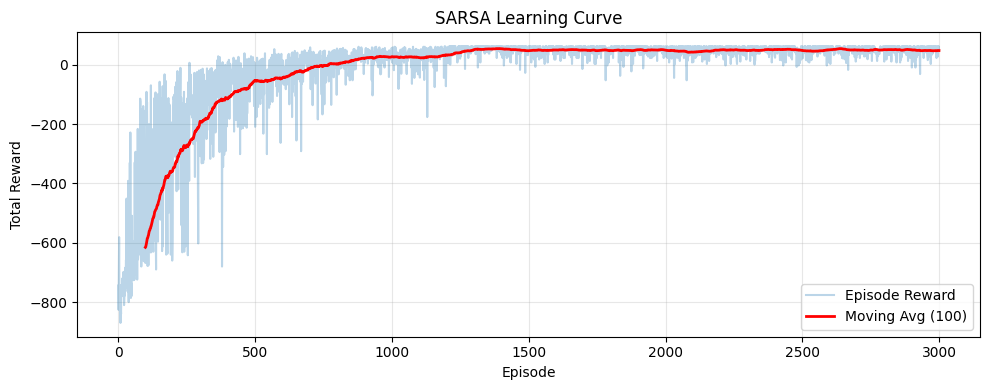

In [16]:
window     = 100
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, label='Episode Reward')
plt.plot(range(window-1, len(episode_rewards)), moving_avg,
         'r-', linewidth=2, label=f'Moving Avg ({window})')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('SARSA Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sarsa_learning_curve.png', dpi=120)
plt.show()

#Manhattan Distance Comparison

In [17]:
def manhattan_distance(start, goal, size):
    sx, sy = divmod(start, size)
    gx, gy = divmod(goal,  size)
    return abs(sx-gx) + abs(sy-gy)

path  = []
state, _ = env.reset()
done, steps = False, 0

while not done and steps < 500:
    steps += 1
    action = int(np.argmax(Q[state]))
    next_state, reward, done, _, _ = env.step(action)
    path.append(state)
    state = next_state

goal     = (env.size-1)*env.cols + (env.size-1)
shortest = manhattan_distance(path[0], goal, env.size)
print(f"Actual steps      : {len(path)}")
print(f"Theoretical min   : {shortest + 1}")

Actual steps      : 40
Theoretical min   : 39


#Trajectory Animation

Steps taken: 44
Saved: sarsa_demo.mp4


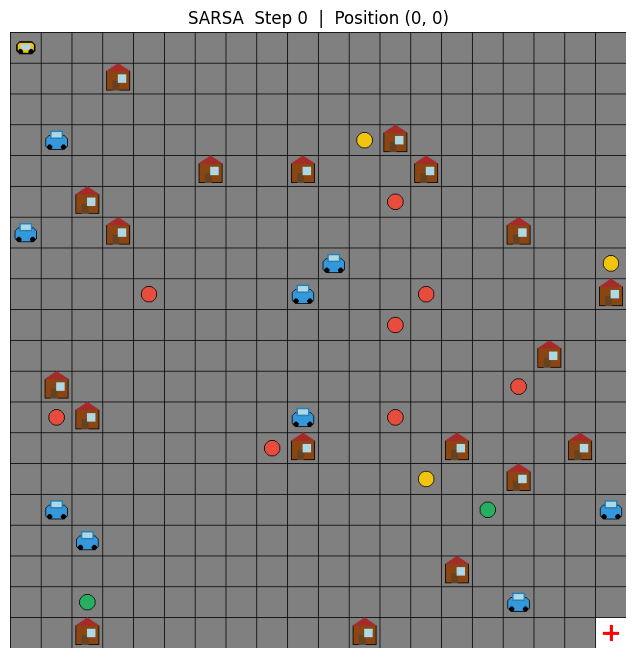

In [18]:
state, _ = env.reset()
done, steps = False, 0
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]
grid_history   = [env._grid.copy()]

while not done and steps < 200:
    steps += 1
    action = int(np.argmax(Q[state]))
    state, reward, done, _, _ = env.step(action)
    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

print(f"Steps taken: {len(states_history)}")

fig, ax = plt.subplots(figsize=(8, 8))

def update(frame):
    ax.clear()
    env._grid = grid_history[frame]
    ax.imshow(env.render_frame(states_history[frame], lights_history[frame]))
    r, c = divmod(states_history[frame], env.cols)
    ax.set_title(f"SARSA  Step {frame}  |  Position ({r}, {c})")
    ax.axis('off')


anim = FuncAnimation(fig, update, frames=len(states_history), interval=150)
anim.save('sarsa_demo.mp4', writer='ffmpeg', fps=8)
print("Saved: sarsa_demo.mp4")
Video('sarsa_demo.mp4', embed=True)